### Tema: Probabilidades e percentis da distribuição Normal em aplicações na Ciência dos Alimentos.

## Atividade Prática - Resolução do Grupo 8

## Integrates
* **Karin Santos** - Nº USP: 15674699
* **Larissa Taffarel** - Nº USP: 14669771

### Exercício: Distribuição Normal aplicada ao Processamento de Alimentos

**Contexto:** O tempo necessário para uma determinada etapa do processamento de um alimento segue uma distribuição Normal com média ($\mu$) de 40 minutos e desvio-padrão ($\sigma$) de 4 minutos.

Seja $X$ o tempo, em minutos, necessário para completar essa etapa.

Vamos resolver as questões passo a passo utilizando Python (`scipy.stats` e `matplotlib`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Definição dos parâmetros da distribuição
mu = 40
sigma = 4
X_dist = norm(loc=mu, scale=sigma)

print(f"Parâmetros definidos: Média (mu) = {mu} min, Desvio-padrão (sigma) = {sigma} min")

Parâmetros definidos: Média (mu) = 40 min, Desvio-padrão (sigma) = 4 min


### 1. Distribuição de probabilidade de $X$ e seus parâmetros

A variável aleatória contínua $X$ representa o tempo de processamento em minutos. A sua distribuição de probabilidade é expressa como:

$$X \sim N(\mu, \sigma^2) \implies X \sim N(40, 16)$$

Onde:
- $\mu = 40$ minutos (média)
- $\sigma = 4$ minutos (desvio-padrão)
- $\sigma^2 = 16$ minutos$^2$ (variância)

### 2, 3 e 4. Cálculos de Probabilidades

*   **Item 2:** Probabilidade do processamento ser concluído em até 35 minutos: $P(X \le 35)$
*   **Item 3:** Probabilidade do processamento levar pelo menos 45 minutos: $P(X \ge 45)$
*   **Item 4:** Probabilidade de o tempo de processamento estar entre 35 e 45 minutos: $P(35 \le X \le 45)$

In [2]:
# 2. P(X <= 35)
p_menor_35 = X_dist.cdf(35)

# 3. P(X >= 45)
p_maior_45 = 1 - X_dist.cdf(45)

# 4. P(35 <= X <= 45)
p_entre_35_45 = X_dist.cdf(45) - X_dist.cdf(35)

print(f"2. P(X <= 35) = {p_menor_35:.4f} ({p_menor_35*100:.2f}%)")
print(f"3. P(X >= 45) = {p_maior_45:.4f} ({p_maior_45*100:.2f}%)")
print(f"4. P(35 <= X <= 45) = {p_entre_35_45:.4f} ({p_entre_35_45*100:.2f}%)")

2. P(X <= 35) = 0.1056 (10.56%)
3. P(X >= 45) = 0.1056 (10.56%)
4. P(35 <= X <= 45) = 0.7887 (78.87%)


```markdown
**Explicação desta etapa:**
Calculamos as probabilidades de interesse prático usando a função de distribuição acumulada (CDF - Cumulative Distribution Function):
* **Item 2 P(X \le 35):** Encontramos a probabilidade do processo terminar em até 35 minutos 10,56%
* **Item 3 P(X \ge 45):** Como a CDF calcula acumulados à esquerda, fazemos a subtração complementar 1 - P(X < 45) para encontrar a probabilidade do processo demorar pelo menos 45 minutos 10,56%.
* **Item 4 P(35 \le X \le 45):** Subtraímos a probabilidade acumulada do limite inferior (35) da do limite superior (45) para obter a probabilidade do tempo estar entre esses valores 78,87%.
```

### 5. Representações Gráficas das Probabilidades

Vamos plotar as curvas normais e destacar as áreas correspondentes às probabilidades calculadas anteriormente.

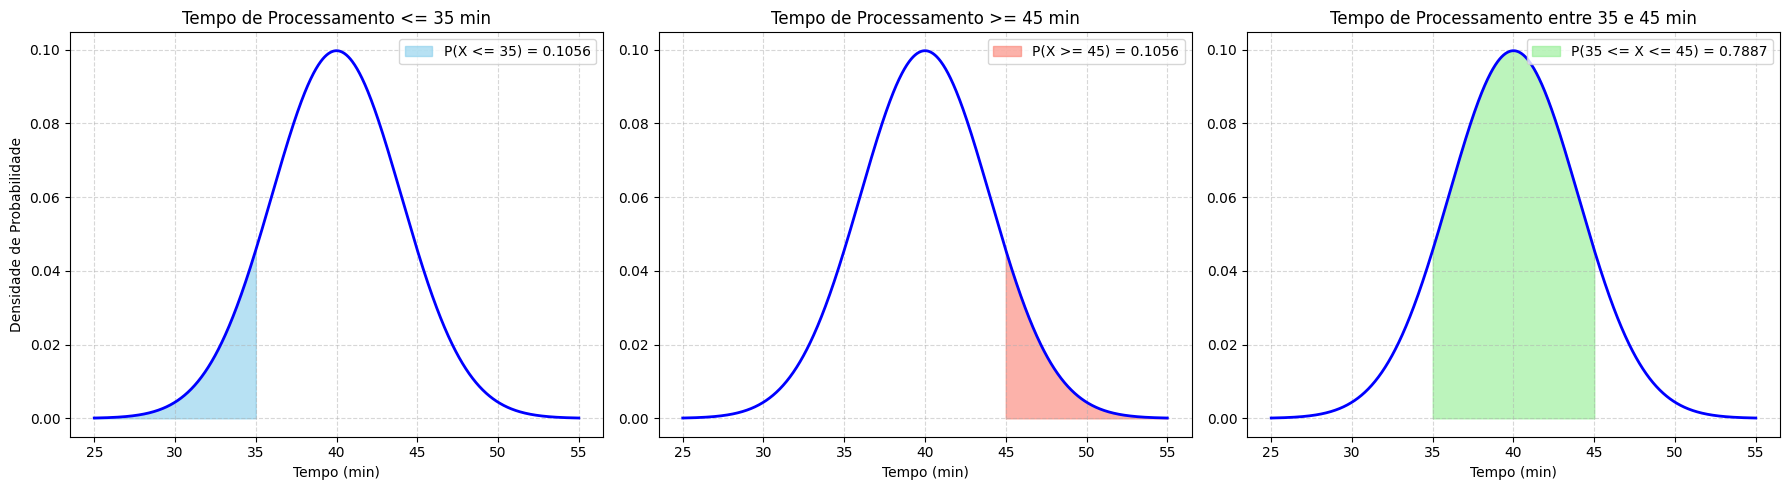

In [3]:
x = np.linspace(25, 55, 1000)
y = X_dist.pdf(x)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: P(X <= 35)
axes[0].plot(x, y, 'b', lw=2)
px1 = np.linspace(25, 35, 100)
axes[0].fill_between(px1, X_dist.pdf(px1), color='skyblue', alpha=0.6, label=f'P(X <= 35) = {p_menor_35:.4f}')
axes[0].set_title('Tempo de Processamento <= 35 min')
axes[0].set_xlabel('Tempo (min)')
axes[0].set_ylabel('Densidade de Probabilidade')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Gráfico 2: P(X >= 45)
axes[1].plot(x, y, 'b', lw=2)
px2 = np.linspace(45, 55, 100)
axes[1].fill_between(px2, X_dist.pdf(px2), color='salmon', alpha=0.6, label=f'P(X >= 45) = {p_maior_45:.4f}')
axes[1].set_title('Tempo de Processamento >= 45 min')
axes[1].set_xlabel('Tempo (min)')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.5)

# Gráfico 3: P(35 <= X <= 45)
axes[2].plot(x, y, 'b', lw=2)
px3 = np.linspace(35, 45, 100)
axes[2].fill_between(px3, X_dist.pdf(px3), color='lightgreen', alpha=0.6, label=f'P(35 <= X <= 45) = {p_entre_35_45:.4f}')
axes[2].set_title('Tempo de Processamento entre 35 e 45 min')
axes[2].set_xlabel('Tempo (min)')
axes[2].legend(loc='upper right')
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

```markdown
**Explicação desta etapa:**
Geramos uma visualização gráfica de cada uma das três probabilidades calculadas anteriormente:
* O eixo horizontal representa o tempo de processamento em minutos.
* O eixo vertical representa a densidade de probabilidade da distribuição.
* As áreas sombreadas (azul, salmão e verde) representam visualmente as proporções (probabilidades) que calculamos. É fácil notar visualmente a perfeita simetria entre o Gráfico 1 e o Gráfico 2.
```

### 6 e 7. Percentis

*   **Item 6:** Percentil 95 do tempo de processamento ($P(X \le P_{95}) = 0.95$).
*   **Item 7:** Tempo limite para que 99% dos processamentos sejam concluídos ($P(X \le P_{99}) = 0.99$).

In [4]:
# 6. Percentil 95
p95 = X_dist.ppf(0.95)

# 7. Percentil 99 (Tempo limite de 99%)
p99 = X_dist.ppf(0.99)

print(f"6. Percentil 95 (P95) = {p95:.2f} minutos")
print(f"7. Tempo Limite para 99% (P99) = {p99:.2f} minutos")

6. Percentil 95 (P95) = 46.58 minutos
7. Tempo Limite para 99% (P99) = 49.31 minutos



**Explicação desta etapa:**
Nesta etapa, calculamos os percentis utilizando a função quantil (PPF - Percent Point Function):
* Em vez de fornecer um tempo e pedir a probabilidade, nós fornecemos a probabilidade desejada 95% e 99% e determinamos qual tempo limite corresponde a ela.
* O Percentil 95 indica que 95% dos lotes são terminados em até 46,58 minutos.
* O Percentil 99 estabelece que 99% dos lotes são finalizados em até 49,31 minutos.


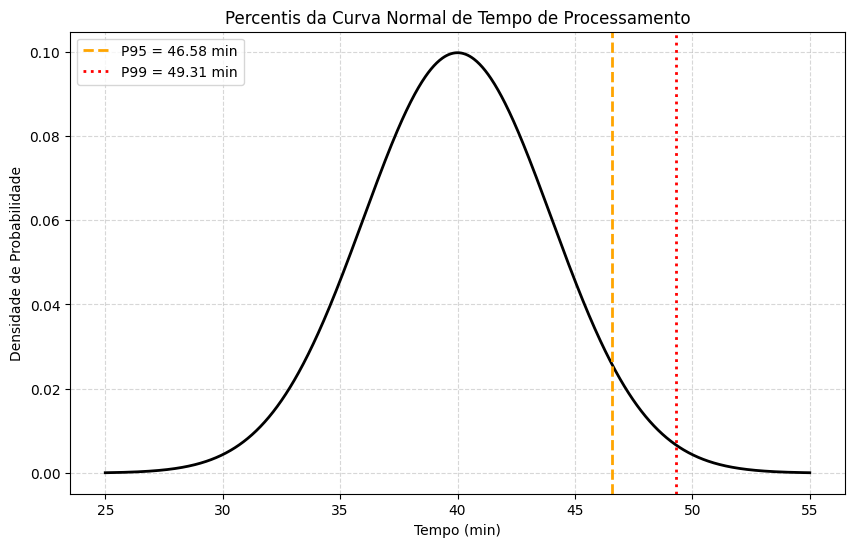

In [5]:
# Gráfico dos Percentis
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'black', lw=2)

# Destaque P95
plt.axvline(p95, color='orange', linestyle='--', lw=2, label=f'P95 = {p95:.2f} min')
# Destaque P99
plt.axvline(p99, color='red', linestyle=':', lw=2, label=f'P99 = {p99:.2f} min')

plt.title('Percentis da Curva Normal de Tempo de Processamento')
plt.xlabel('Tempo (min)')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


**Explicação desta etapa:**
Este gráfico plota a distribuição normal completa e insere duas linhas verticais para marcar os percentis calculados:
* A linha pontilhada laranja representa o ponto em que acumulamos 95% da área (restreando apenas 5% à sua direita).
* A linha pontilhada vermelha mostra o limite mais seguro, onde acumulamos 99% de toda a área sob a curva (restando apenas 1% à direita).


### 8. Interpretação e Comparação (Ciência dos Alimentos)

*   **Percentil 95 (\~46.58 min):** Significa que 95% de todos os lotes ou amostras processadas nesta etapa serão concluídos em até 46.58 minutos. Há apenas uma chance de 5% de que um lote leve mais tempo do que isso.
*   **Percentil 99 (\~49.31 min):** Significa que sob condições normais de variabilidade, 99% dos processamentos serão concluídos em até 49.31 minutos. Apenas 1% das operações ultrapassarão essa marca.

**Comparação:** O estabelecimento de um tempo limite de 49.31 minutos (P99) garante uma margem de segurança operacional significativamente maior (99%) em comparação aos 46.58 minutos (P95). Em termos práticos de controle de qualidade e planejamento de fábrica, planejar com base no percentil 99 minimiza quase por completo atrasos nas etapas subsequentes de produção, embora exija uma maior janela de tempo reservada no cronograma produtivo.